<a href="https://colab.research.google.com/github/christy5165/Denoising_Autoencoder.ipynb/blob/main/DCGAN-WK-8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Training DCGAN (This may take a minute)...
Epoch [0/500] Loss D: 1.1670, Loss G: 0.9151
Epoch [100/500] Loss D: 0.0189, Loss G: 4.6349
Epoch [200/500] Loss D: 0.0171, Loss G: 4.6561
Epoch [300/500] Loss D: 0.0564, Loss G: 4.3522
Epoch [400/500] Loss D: 0.0986, Loss G: 3.2918

Generated Images:


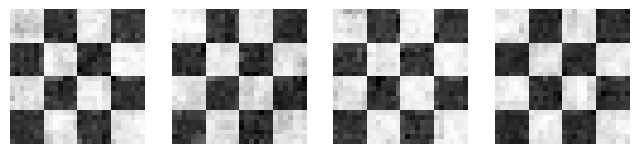

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

# ---------------------------------------------------------
# 1. CREATE SYNTHETIC "CHECKERBOARD" DATA
# ---------------------------------------------------------
def get_checkerboard_data(n=1000):
    # Creates 28x28 images with a 4x4 checkerboard pattern
    data = torch.zeros((n, 1, 28, 28))
    for i in range(0, 28, 7):
        for j in range(0, 28, 7):
            if (i // 7 + j // 7) % 2 == 0:
                data[:, :, i:i+7, j:j+7] = 1.0
    # Add a tiny bit of noise so it's not "too" perfect for the GAN
    return data + torch.randn_like(data) * 0.05

# ---------------------------------------------------------
# 2. DEFINE DCGAN MODELS
# ---------------------------------------------------------
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.main = nn.Sequential(
            # Input is 100 random numbers (Latent Vector)
            nn.ConvTranspose2d(100, 128, 7, 1, 0, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            # Upsample to 14x14
            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            # Upsample to 28x28
            nn.ConvTranspose2d(64, 1, 4, 2, 1, bias=False),
            nn.Tanh()
        )
    def forward(self, x):
        return self.main(x)

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.main = nn.Sequential(
            nn.Conv2d(1, 64, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(128, 1, 7, 1, 0, bias=False),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.main(x).view(-1, 1)

# Initialize
netG = Generator()
netD = Discriminator()
optimizerD = optim.Adam(netD.parameters(), lr=0.0002, betas=(0.5, 0.999))
optimizerG = optim.Adam(netG.parameters(), lr=0.0002, betas=(0.5, 0.999))
criterion = nn.BCELoss()

# ---------------------------------------------------------
# 3. TRAINING
# ---------------------------------------------------------
epochs = 500
batch_size = 32

print("Training DCGAN (This may take a minute)...")
for epoch in range(epochs):
    # Train Discriminator
    netD.zero_grad()
    real_images = get_checkerboard_data(batch_size)
    output = netD(real_images)
    lossD_real = criterion(output, torch.ones(batch_size, 1))

    noise = torch.randn(batch_size, 100, 1, 1)
    fake_images = netG(noise)
    output = netD(fake_images.detach())
    lossD_fake = criterion(output, torch.zeros(batch_size, 1))

    lossD = lossD_real + lossD_fake
    lossD.backward()
    optimizerD.step()

    # Train Generator
    netG.zero_grad()
    output = netD(fake_images)
    lossG = criterion(output, torch.ones(batch_size, 1))
    lossG.backward()
    optimizerG.step()

    if epoch % 100 == 0:
        print(f"Epoch [{epoch}/{epochs}] Loss D: {lossD.item():.4f}, Loss G: {lossG.item():.4f}")

# ---------------------------------------------------------
# 4. DISPLAY RESULTS
# ---------------------------------------------------------
print("\nGenerated Images:")
with torch.no_grad():
    test_noise = torch.randn(4, 100, 1, 1)
    generated = netG(test_noise).cpu()

plt.figure(figsize=(8, 2))
for i in range(4):
    plt.subplot(1, 4, i+1)
    plt.imshow(generated[i].squeeze(), cmap='gray')
    plt.axis('off')
plt.show()